<a href="https://colab.research.google.com/github/crahulnaidu/quantum_computing/blob/main/month_1/month_1_day_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.9 MB/s eta 0:00:00


In [16]:
import numpy as np
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [4]:
def dj_oracle(case, n):

    oracle_qc = QuantumCircuit(n+1)

    if case == "balanced":

        b = np.random.randint(1,2**n)

        b_str = format(b, '0'+str(n)+'b')

        for qubit in range(len(b_str)):
            if b_str[qubit] == '1':
                oracle_qc.x(qubit)

        for qubit in range(n):
            oracle_qc.cx(qubit, n)

        for qubit in range(len(b_str)):
            if b_str[qubit] == '1':
                oracle_qc.x(qubit)

    #
    if case == "constant":

        output = np.random.randint(2)
        if output == 1:
            oracle_qc.x(n)

    oracle_gate = oracle_qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

In [5]:
def dj_algorithm(oracle, n):
    dj_circuit = QuantumCircuit(n+1, n)

    dj_circuit.x(n)
    dj_circuit.h(n)

    for qubit in range(n):
        dj_circuit.h(qubit)

    dj_circuit.append(oracle, range(n+1))

    for qubit in range(n):
        dj_circuit.h(qubit)

    for i in range(n):
        dj_circuit.measure(i, i)

    return dj_circuit

In [7]:
n = 5
oracle_gate = dj_oracle('balanced', n)
dj_circuit = dj_algorithm(oracle_gate, n)
dj_circuit.draw()


┌───┐     ┌─────────┐┌───┐┌─┐            
q_0: ┤ H ├─────┤0        ├┤ H ├┤M├────────────
     ├───┤     │         │├───┤└╥┘┌─┐         
q_1: ┤ H ├─────┤1        ├┤ H ├─╫─┤M├─────────
     ├───┤     │         │├───┤ ║ └╥┘┌─┐      
q_2: ┤ H ├─────┤2        ├┤ H ├─╫──╫─┤M├──────
     ├───┤     │  Oracle │├───┤ ║  ║ └╥┘┌─┐   
q_3: ┤ H ├─────┤3        ├┤ H ├─╫──╫──╫─┤M├───
     ├───┤     │         │├───┤ ║  ║  ║ └╥┘┌─┐
q_4: ┤ H ├─────┤4        ├┤ H ├─╫──╫──╫──╫─┤M├
     ├───┤┌───┐│         │└───┘ ║  ║  ║  ║ └╥┘
q_5: ┤ X ├┤ H ├┤5        ├──────╫──╫──╫──╫──╫─
     └───┘└───┘└─────────┘      ║  ║  ║  ║  ║ 
c: 5/═══════════════════════════╩══╩══╩══╩══╩═
                                0  1  2  3  4

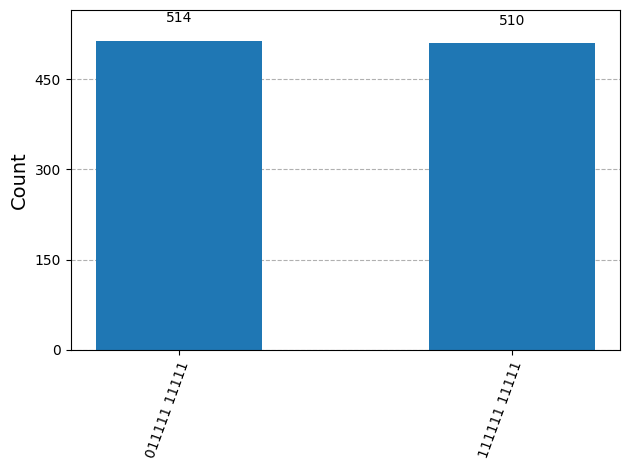

In [18]:
aer_sim=AerSimulator()
transpiled_dj_circuit = transpile(dj_circuit, aer_sim)
results = aer_sim.run(transpiled_dj_circuit).result()
answer = results.get_counts()
plot_histogram(answer)